<a href="https://colab.research.google.com/github/Irdina-lurve/GROUP-E-SDG12/blob/main/ML_GROUP_E_SDG12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ASSIGNMENT DESCRIPTION

UN SDG: Goal 12 - Responsible Consumption
Target 12.3: Halve per capita global food waste at retail and consumer levels by 2023
Target 12.5: Substantially reduce waste generation through prevention, reduction, recycling and reuse

Research Questions:
1. Can we accurately predict daily food waste volume (in kg) based on historical patterns?
2. What factors influence food waste?
3. Do sales prediction models help reduce waste indirectly by improving demand forecasting?

Datasets:
1. Kaggle: Food Waste
2. Kaggle: Restaurant Sales

# Datasets Used

In [ ]:
# DATASET 1: FOOD WASTE
import os
import kagglehub
import pandas as pd

path1 = kagglehub.dataset_download("joebeachcapital/food-waste")
print(f"Path: {path1}")

files1 = os.listdir(path1)
print(f"Files: {files1}")

csv_files1 = [f for f in files1 if f.endswith(".csv")]

if csv_files1:
    df1 = pd.read_csv(os.path.join(path1, csv_files1[0]))

    print("\nDataset 1 loaded:")
    print(df1.shape)

    print("\nColumns:")
    print(df1.columns.tolist())

    print("\nFirst 3 rows:")
    display(df1.head(3))

    print("\nMissing values:")
    print(df1.isnull().sum().sum())

else:
    print("No CSV file found")
    df1 = None

Using Colab cache for faster access to the 'food-waste' dataset.
Path: /kaggle/input/food-waste
Files: ['Food Waste data and research - by country.csv']

Dataset 1 loaded:
(214, 12)

Columns:
['Country', 'combined figures (kg/capita/year)', 'Household estimate (kg/capita/year)', 'Household estimate (tonnes/year)', 'Retail estimate (kg/capita/year)', 'Retail estimate (tonnes/year)', 'Food service estimate (kg/capita/year)', 'Food service estimate (tonnes/year)', 'Confidence in estimate', 'M49 code', 'Region', 'Source']

First 3 rows:


,Country,combined figures (kg/capita/year),Household estimate (kg/capita/year),Household estimate (tonnes/year),Retail estimate (kg/capita/year),Retail estimate (tonnes/year),Food service estimate (kg/capita/year),Food service estimate (tonnes/year),Confidence in estimate,M49 code,Region,Source
0,Afghanistan,126,82,3109153,16,594982,28,1051783,Very Low Confidence,4,Southern Asia,https://www.unep.org/resources/report/unep-foo...
1,Albania,127,83,238492,16,45058,28,79651,Very Low Confidence,8,Southern Europe,https://www.unep.org/resources/report/unep-foo...
2,Algeria,135,91,3918529,16,673360,28,1190335,Very Low Confidence,12,Northern Africa,https://www.unep.org/resources/report/unep-foo...



Missing values:
0


In [ ]:
# DATASET 2: RESTAURANT SALES
import os
import kagglehub
import pandas as pd

path2 = kagglehub.dataset_download("rohitgrewal/restaurant-sales-data")
print(f"Path: {path2}")

files2 = os.listdir(path2)
print(f"Files: {files2}")

csv_files2 = [f for f in files2 if f.endswith(".csv")]

if csv_files2:
    df2 = pd.read_csv(os.path.join(path2, csv_files2[0]))

    print("\nDataset 2 loaded:")
    print(df2.shape)

    print("\nColumns:")
    print(df2.columns.tolist())

    print("\nFirst 3 rows:")
    display(df2.head(3))

    print("\nMissing values:")
    print(df2.isnull().sum().sum())

else:
    print("No CSV file found")
    df2 = None

Using Colab cache for faster access to the 'restaurant-sales-data' dataset.
Path: /kaggle/input/restaurant-sales-data
Files: ['9. Sales-Data-Analysis.csv']

Dataset 2 loaded:
(254, 9)

Columns:
['Order ID', 'Date', 'Product', 'Price', 'Quantity', 'Purchase Type', 'Payment Method', 'Manager', 'City']

First 3 rows:


,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon



Missing values:
0


# Part A - Data Preprocessing

In [ ]:
import os
import kagglehub
import numpy as np
import pandas as pd
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from IPython.display import display
from datetime import datetime

In [ ]:
np.random.seed(42)
print("PART A: Data Preprocessing")
print("SDG 12 - Responsible Consumption (Food Waste Prediction)")

path = kagglehub.dataset_download("joebeachcapital/food-waste")
print(f"Download path: {path}")

# Find and load CSV file
files = os.listdir(path)
csv_files = [f for f in files if f.endswith(".csv")]

if csv_files:
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    print(f"Loaded: {csv_files[0]}")
else:
    print("No CSV file found.")
    df = None

if df is not None:
    print(f"\nDataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

    print("\nFirst 5 rows:")
    display(df.head())

def preprocess_food_waste(df):
    """Preprocess Food Waste dataset for regression"""

    df1 = df.copy()
    print(f"\nOriginal columns: {df1.columns.tolist()}")

# ============================================================
# 1. DATA CLEANING (handling missing values)
# ============================================================
print("\n" + "=" * 40)
print("1. Handling missing values")

duplicate_count = df1.duplicated().sum()
print(f"Duplicate rows before: {duplicate_count}")

df1 = df1.drop_duplicates()

print(f"Duplicate rows after: {df1.duplicated().sum()}")
print(f"\nMissing values before: {df1.isnull().sum().sum()}")

for col in df1.columns:
  if df1[col].isnull().sum() > 0:
    if df1[col].dtype in ["int64", "float64"]:
      df1[col] = df1[col].fillna(df1[col].median())

    else:
      df1[col] = df1[col].fillna(df1[col].mode()[0])

print(f"Missing values after: {df1.isnull().sum().sum()}")

# ============================================================
# 2. SELECT TARGET COLUMN SAFELY
# ============================================================
print("\n" + "=" * 40)
print("2. Selecting target column")

print("\nAvailable columns:")
for i, col in enumerate(df1.columns):
    print(i, col)

waste_cols = [col for col in df1.columns if "waste" in col.lower()]

print("\nWaste-related columns found:")
print(waste_cols)

target_col = None
best_valid_count = 0

# Choose the waste-related column with the most numeric values
for col in waste_cols:
    numeric_version = pd.to_numeric(df1[col], errors="coerce")
    valid_count = numeric_version.notna().sum()

    print(f"{col}: {valid_count} valid numeric values out of {len(df1)}")

    if valid_count > best_valid_count:
        best_valid_count = valid_count
        target_col = col

# Fallback if no numeric waste column is found
if target_col is None or best_valid_count == 0:
    numeric_cols = df1.select_dtypes(include=["int64", "float64"]).columns.tolist()

    if len(numeric_cols) == 0:
        raise ValueError("No suitable numeric target column found.")

    target_col = numeric_cols[-1]
    print(f"\nNo numeric waste column found. Using fallback numeric target: {target_col}")
else:
    print(f"\nTarget column selected: {target_col}")

# Convert target to numeric
df1[target_col] = pd.to_numeric(df1[target_col], errors="coerce")

print(f"Missing target values before cleaning: {df1[target_col].isnull().sum()}")

# If target still has NaN, drop those rows
df1 = df1.dropna(subset=[target_col])

print(f"Missing target values after cleaning: {df1[target_col].isnull().sum()}")
print(f"Dataset shape after target cleaning: {df1.shape}")

# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================
print("\n" + "=" * 40)
print("3. Feature engineering")

date_columns = [col for col in df1.columns if 'date' in col.lower()]

if date_columns:
    date_col = date_columns[0]
    df1[date_col] = pd.to_datetime(df1[date_col], errors='coerce')
    df1['day_of_week'] = df1[date_col].dt.dayofweek
    df1['is_weekend'] = df1['day_of_week'].isin([5, 6]).astype(int)
    df1['month'] = df1[date_col].dt.month

    df1 = df1.drop(columns=[date_col])
    print(f"Created: day_of_week, is_weekend, month from {date_col}")
else:
    print("No date column found. Date-based features were not created.")

waste_cols = [col for col in df1.columns if 'waste' in col.lower()]
prep_cols = [col for col in df1.columns if 'prep' in col.lower() or 'amount' in col.lower()]

print("Waste columns found:", waste_cols)
print("Prep/Amount columns found:", prep_cols)

if waste_cols and prep_cols and waste_cols[0] != target_col:
    df1['waste_ratio'] = df1[waste_cols[0]] / (df1[prep_cols[0]] + 0.01)
    print(f"Created: waste_ratio from {waste_cols[0]} and {prep_cols[0]}")
else:
    print("Waste ratio was not created because suitable waste and prep/amount columns were not available.")

# ============================================================
# 4. ENCODING CATEGORICAL VARIABLES
# ============================================================
print("\n" + "=" * 40)
print("4. Encoding categorical variables")

# Get all categorical columns
categorical_cols = df1.select_dtypes(include=['object']).columns
print(f"Categorical columns found: {categorical_cols.tolist()}")

# Encode each categorical column
label_encoders1 = {}

for col in categorical_cols:
    if col != target_col:  # Don't encode the target
        le = LabelEncoder()
        df1[col] = le.fit_transform(df1[col].astype(str))
        label_encoders1[col] = le
        print(f"Encoded: {col}")

print("Encoding completed.")

# ============================================================
# 5. HANDLE OUTLIERS
# ============================================================
print("\n" + "=" * 40)
print("5. Handling outliers using IQR")

numeric_cols = df1.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    if col != target_col:
        Q1 = df1[col].quantile(0.25)
        Q3 = df1[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df1[col] = df1[col].clip(lower_bound, upper_bound)

print("Outliers handled.")

# ============================================================
# 6. DATA SPLITTING
# ============================================================
print("\n" + "=" * 40)
print("6. Splitting features and target")

df1 = df1.replace([np.inf, -np.inf], np.nan)

for col in df1.columns:
    if df1[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df1[col]):
            df1[col] = df1[col].fillna(df1[col].median())
        else:
            df1[col] = df1[col].fillna(df1[col].mode()[0])

# Make sure target has no NaN
df1 = df1.dropna(subset=[target_col])

X1 = df1.drop(columns=[target_col])
y1 = df1[target_col]

# Keep numeric features only
non_numeric = X1.select_dtypes(exclude=["number"]).columns

if len(non_numeric) > 0:
    print(f"Dropping non-numeric columns: {non_numeric.tolist()}")
    X1 = X1.drop(columns=non_numeric)

# Final X cleaning
X1 = X1.replace([np.inf, -np.inf], np.nan)

for col in X1.columns:
    if X1[col].isnull().sum() > 0:
        X1[col] = X1[col].fillna(X1[col].median())

print(f"Missing values in X1: {X1.isnull().sum().sum()}")
print(f"Missing values in y1: {y1.isnull().sum()}")

print(f"Features shape: {X1.shape}")
print(f"Target shape: {y1.shape}")
print(f"Target stats: mean={y1.mean():.2f}, min={y1.min():.2f}, max={y1.max():.2f}")

if len(X1) == 0:
    raise ValueError("Dataset is empty after preprocessing. Please check target column selection.")

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X1_train.shape}")
print(f"Test : {X1_test.shape}")

# ============================================================
# 7. DATA SCALING
# ============================================================
print("\n" + "=" * 40)
print("7. Scaling features using StandardScaler")

scaler1 = StandardScaler()

X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

X1_train_scaled = pd.DataFrame(X1_train_scaled, columns=X1_train.columns)
X1_test_scaled = pd.DataFrame(X1_test_scaled, columns=X1_test.columns)

# Keep y index aligned and clean
y1_train = pd.Series(y1_train).reset_index(drop=True)
y1_test = pd.Series(y1_test).reset_index(drop=True)

X1_train_scaled = X1_train_scaled.reset_index(drop=True)
X1_test_scaled = X1_test_scaled.reset_index(drop=True)

print(f"Scaled {X1_train_scaled.shape[1]} features")
print("NaN in y1_train:", y1_train.isnull().sum())
print("NaN in y1_test :", y1_test.isnull().sum())

# ============================================================
# 8. SAVE PROCESSED DATA
# ============================================================
print("\n" + "=" * 40)
print("8. Saving processed data")

os.makedirs("/content/food_waste_processed", exist_ok=True)

X1_train_scaled.to_csv("/content/food_waste_processed/X1_train_scaled.csv", index=False)
X1_test_scaled.to_csv("/content/food_waste_processed/X1_test_scaled.csv", index=False)
y1_train.to_csv("/content/food_waste_processed/y1_train.csv", index=False)
y1_test.to_csv("/content/food_waste_processed/y1_test.csv", index=False)

joblib.dump(label_encoders1, "/content/food_waste_processed/label_encoders1.pkl")
joblib.dump(scaler1, "/content/food_waste_processed/scaler1.pkl")

print("All files and dataset processed and saved.")

PART A: Data Preprocessing
SDG 12 - Responsible Consumption (Food Waste Prediction)
Using Colab cache for faster access to the 'food-waste' dataset.
Download path: /kaggle/input/food-waste
Loaded: Food Waste data and research - by country.csv

Dataset shape: (214, 12)
Columns: ['Country', 'combined figures (kg/capita/year)', 'Household estimate (kg/capita/year)', 'Household estimate (tonnes/year)', 'Retail estimate (kg/capita/year)', 'Retail estimate (tonnes/year)', 'Food service estimate (kg/capita/year)', 'Food service estimate (tonnes/year)', 'Confidence in estimate', 'M49 code', 'Region', 'Source']

First 5 rows:


,Country,combined figures (kg/capita/year),Household estimate (kg/capita/year),Household estimate (tonnes/year),Retail estimate (kg/capita/year),Retail estimate (tonnes/year),Food service estimate (kg/capita/year),Food service estimate (tonnes/year),Confidence in estimate,M49 code,Region,Source
0,Afghanistan,126,82,3109153,16,594982,28,1051783,Very Low Confidence,4,Southern Asia,https://www.unep.org/resources/report/unep-foo...
1,Albania,127,83,238492,16,45058,28,79651,Very Low Confidence,8,Southern Europe,https://www.unep.org/resources/report/unep-foo...
2,Algeria,135,91,3918529,16,673360,28,1190335,Very Low Confidence,12,Northern Africa,https://www.unep.org/resources/report/unep-foo...
3,Andorra,123,84,6497,13,988,26,1971,Low Confidence,20,Southern Europe,https://www.unep.org/resources/report/unep-foo...
4,Angola,144,100,3169523,16,497755,28,879908,Very Low Confidence,24,Sub-Saharan Africa,https://www.unep.org/resources/report/unep-foo...



1. Handling missing values
Duplicate rows before: 0
Duplicate rows after: 0

Missing values before: 0
Missing values after: 0

2. Selecting target column

Available columns:
0 Country
1 combined figures (kg/capita/year)
2 Household estimate (kg/capita/year)
3 Household estimate (tonnes/year)
4 Retail estimate (kg/capita/year)
5 Retail estimate (tonnes/year)
6 Food service estimate (kg/capita/year)
7 Food service estimate (tonnes/year)
8 Confidence in estimate
9 M49 code
10 Region
11 Source

Waste-related columns found:
[]

No numeric waste column found. Using fallback numeric target: M49 code
Missing target values before cleaning: 0
Missing target values after cleaning: 0
Dataset shape after target cleaning: (214, 12)

3. Feature engineering
No date column found. Date-based features were not created.
Waste columns found: []
Prep/Amount columns found: []
Waste ratio was not created because suitable waste and prep/amount columns were not available.

4. Encoding categorical variables
Cat

In [ ]:
if df2 is not None:
  df2_processed = df2.copy()

  print("\nPART A: Data Preprocessing - Dataset 2")
  print("=" * 60)
  print(f"\nOriginal columns: {df2_processed.columns.tolist()}")

# ============================================================
# 1. DATA CLEANING (handling missing values)
# ============================================================
print("\n" + "=" * 40)
print("1. Handling missing values and duplicates")

duplicate_count = df2_processed.duplicated().sum()
print(f"Duplicate rows before: {duplicate_count}")

df2_processed = df2_processed.drop_duplicates()

print(f"Duplicate rows after: {df2_processed.duplicated().sum()}")
print(f"Missing values before: {df2_processed.isnull().sum().sum()}")

for col in df2_processed.columns:
  if df2_processed[col].isnull().sum() > 0:
    if df2_processed[col].dtype in ["int64", "float64"]:
      df2_processed[col] = df2_processed[col].fillna(df2_processed[col].median())
      print(f"Imputed '{col}' with median")

    else:
      df2_processed[col] = df2_processed[col].fillna(df2_processed[col].mode()[0])
      print(f"Imputed '{col}' with mode")

print(f"Missing values after: {df2_processed.isnull().sum().sum()}")

# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================
print("\n" + "=" * 40)
print("2. Feature engineering")

# Find date column
date_columns = [col for col in df2_processed.columns if "date" in col.lower()]

if date_columns:
  date_col = date_columns[0]

  df2_processed[date_col] = pd.to_datetime(df2_processed[date_col], errors="coerce")
  df2_processed = df2_processed.sort_values(date_col)
  df2_processed["day_of_week"] = df2_processed[date_col].dt.dayofweek
  df2_processed["is_weekend"] = df2_processed["day_of_week"].isin([5, 6]).astype(int)
  df2_processed["month"] = df2_processed[date_col].dt.month

  df2 = df2.drop(columns=[date_col])
  print(f"Created: day_of_week, is_weekend, month from {date_col}")

else:
  date_col = None
  print("No date column found. Creating index-based time features.")

  df2_processed["day_of_week"] = np.arange(len(df2_processed)) % 7
  df2_processed["is_weekend"] = df2_processed["day_of_week"].isin([5, 6]).astype(int)
  df2_processed["month"] = ((np.arange(len(df2_processed)) // 30) % 12) + 1

# Find sales / quantity / revenue column
sales_cols = [
    col for col in df2_processed.columns
    if "sales" in col.lower()
    or "quantity" in col.lower()
    or "revenue" in col.lower()
    or "amount" in col.lower()
    or "price" in col.lower()
]

if len(sales_cols) > 0:
  sales_col = sales_cols[0]
  print(f"Using '{sales_col}' as sales column")
else:
  numeric_cols = df2_processed.select_dtypes(include=["int64", "float64"]).columns.tolist()

  if len(numeric_cols) > 0:
    sales_col = numeric_cols[0]
    print(f"No sales-related column found. Using '{sales_col}' as sales column.")
  else:
    raise ValueError("No numeric column found for sales-based feature engineering.")

# Rolling features
df2_processed["sales_rolling_avg_3"] = df2_processed[sales_col].rolling(window=3, min_periods=1).mean()
df2_processed["sales_rolling_avg_7"] = df2_processed[sales_col].rolling(window=7, min_periods=1).mean()
df2_processed["sales_rolling_std_3"] = df2_processed[sales_col].rolling(window=3, min_periods=1).std()
df2_processed["sales_rolling_std_7"] = df2_processed[sales_col].rolling(window=7, min_periods=1).std()

df2_processed["sales_volatility"] = (df2_processed["sales_rolling_std_7"] / (df2_processed["sales_rolling_avg_7"] + 0.01))

print("Created: rolling averages, rolling standard deviation, sales volatility")

# Lag features
df2_processed["sales_lag_1"] = df2_processed[sales_col].shift(1)
df2_processed["sales_lag_2"] = df2_processed[sales_col].shift(2)
df2_processed["sales_lag_3"] = df2_processed[sales_col].shift(3)

print("Created: sales_lag_1, sales_lag_2, sales_lag_3")

# Handle missing values caused by rolling std and lag features
df2_processed = df2_processed.replace([np.inf, -np.inf], np.nan)

for col in df2_processed.columns:
  if df2_processed[col].isnull().sum() > 0:
    if df2_processed[col].dtype in ["int64", "float64"]:
      df2_processed[col] = df2_processed[col].fillna(df2_processed[col].median())
    else:
      df2_processed[col] = df2_processed[col].fillna(df2_processed[col].mode()[0])

# ============================================================
# 2. CREATE or SELECT TARGET COLUMN (data transformation)
# ============================================================
print("\n" + "=" * 40)
print("3. Create target column")

target_col = "waste_risk"

df2_processed["waste_risk_score"] = df2_processed["sales_volatility"]
threshold = df2_processed["waste_risk_score"].median()

df2_processed[target_col] = (df2_processed["waste_risk_score"] > threshold).astype(int)

print("Created target column: waste_risk")
print(f"Threshold: {threshold:.4f}")
print("\nTarget distribution:")
print(f"Low risk (0): {(df2_processed[target_col]==0).sum()} ({((df2_processed[target_col]==0).sum()/len(df2_processed))*100:.1f}%)")
print(f"High risk (1): {(df2_processed[target_col]==1).sum()} ({((df2_processed[target_col]==1).sum()/len(df2_processed))*100:.1f}%)")

# ============================================================
# 4. ENCODING CATEGORICAL VARIABLES
# ============================================================
print("\n" + "=" * 40)
print("4. Encoding categorical variables")

# Get all categorical columns
categorical_cols = df2_processed.select_dtypes(include=["object"]).columns
categorical_cols = [col for col in categorical_cols if col != target_col]

# Encode each categorical column
label_encoders2 = {}

for col in categorical_cols:
  le = LabelEncoder()
  df2_processed[col] = le.fit_transform(df2_processed[col].astype(str))
  label_encoders2[col] = le
  print(f"Encoded: {col}")

# ============================================================
# 5. HANDLE OUTLIERS
# ============================================================
print("\n" + "=" * 40)
print("5. Handling outliers using IQR")

numeric_cols = df2_processed.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
  if col not in [target_col, "waste_risk_score"]:
    Q1 = df2_processed[col].quantile(0.25)
    Q3 = df2_processed[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df2_processed[col] = df2_processed[col].clip(lower_bound, upper_bound)

print("Outliers handled using IQR clipping.")

# ============================================================
# 6. FEATURE and DATA SPLITTING
# ============================================================
print("\n" + "=" * 40)
print("6. Splitting features and target")

drop_cols = [target_col, "waste_risk_score"]

if date_col is not None:
  drop_cols.append(date_col)

X2 = df2_processed.drop(columns=drop_cols)
y2 = df2_processed[target_col]

# Handle infinite and missing values
X2 = X2.replace([np.inf, -np.inf], np.nan)

for col in X2.columns:
  if X2[col].isnull().sum() > 0:
    X2[col] = X2[col].fillna(X2[col].median())

X2 = X2.astype(float)
print(f"Features shape: {X2.shape}")
print(f"Target shape: {y2.shape}")

# ============================================================
# 7. TRAIN-TEST SPLIT
# ============================================================
print("\n" + "=" * 40)
print("7. Train-Test Split")

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

print(f"Train: {X2_train.shape}")
print(f"Test : {X2_test.shape}")
print(f"Train class distribution: {y2_train.mean() * 100:.1f}% High risk")
print(f"Test class distribution: {y2_test.mean() * 100:.1f}% High risk")

# ============================================================
# 8. FEATURE SCALING
# ============================================================
print("\n" + "=" * 40)
print("8. Feature Scaling using StandardScaler")

scaler2 = StandardScaler()

X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

X2_train_scaled = pd.DataFrame(X2_train_scaled, columns=X2_train.columns)
X2_test_scaled = pd.DataFrame(X2_test_scaled, columns=X2_test.columns)

print(f"Scaled {X2_train_scaled.shape[1]} features")

# ============================================================
# 9. SAVE PROCESSED DATA
# ============================================================
print("\n" + "=" * 40)
print("9. Save Processed Data")

os.makedirs("/content/sales_processed", exist_ok=True)

X2_train_scaled.to_csv("/content/sales_processed/X2_train_scaled.csv", index=False)
X2_test_scaled.to_csv("/content/sales_processed/X2_test_scaled.csv", index=False)
y2_train.to_csv("/content/sales_processed/y2_train.csv", index=False)
y2_test.to_csv("/content/sales_processed/y2_test.csv", index=False)

joblib.dump(scaler2, "/content/sales_processed/scaler2.pkl")
joblib.dump(label_encoders2, "/content/sales_processed/label_encoders2.pkl")

print("All files saved to /content/sales_processed/")


PART A: Data Preprocessing - Dataset 2

Original columns: ['Order ID', 'Date', 'Product', 'Price', 'Quantity', 'Purchase Type', 'Payment Method', 'Manager', 'City']

1. Handling missing values and duplicates
Duplicate rows before: 0
Duplicate rows after: 0
Missing values before: 0
Missing values after: 0

2. Feature engineering
Created: day_of_week, is_weekend, month from Date
Using 'Price' as sales column
Created: rolling averages, rolling standard deviation, sales volatility
Created: sales_lag_1, sales_lag_2, sales_lag_3

3. Create target column
Created target column: waste_risk
Threshold: 0.5914

Target distribution:
Low risk (0): 129 (50.8%)
High risk (1): 125 (49.2%)

4. Encoding categorical variables
Encoded: Product
Encoded: Purchase Type
Encoded: Payment Method
Encoded: Manager
Encoded: City

5. Handling outliers using IQR
Outliers handled using IQR clipping.

6. Splitting features and target
Features shape: (254, 19)
Target shape: (254,)

7. Train-Test Split
Train: (203, 19)


# Part B - Machine Learning Models

**RQ1 : Can we accurately predict daily food waste volume (in kg) based on historical patterns?**

In [ ]:
# ============================================================
# PART B - DATASET 1: FOOD WASTE PREDICTION
# Regression Models
# ============================================================
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\nPART B: Machine Learning Models")
print("Dataset 1 - Food Waste Regression")
print("=" * 60)

print("Training data:", X1_train_scaled.shape)
print("Testing data :", X1_test_scaled.shape)
print("NaN in y1_train:", y1_train.isnull().sum())
print("NaN in y1_test :", y1_test.isnull().sum())


PART B: Machine Learning Models
Dataset 1 - Food Waste Regression
Training data: (171, 11)
Testing data : (43, 11)
NaN in y1_train: 0
NaN in y1_test : 0


In [ ]:
# ============================================================
# RQ1 : REGRESSION EVALUATION FUNCTION
# ============================================================

def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    result = {
        "Model": model_name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "MAE": mae,
        "RMSE": rmse
    }

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Train R2 : {train_r2:.4f}")
    print(f"Test R2  : {test_r2:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"RMSE     : {rmse:.4f}")

    return result

In [ ]:
# ============================================================
# RQ1: BASELINE REGRESSION MODELS
# ============================================================

rq1_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "kNN Regressor": KNeighborsRegressor(),
    "Support Vector Regressor": SVR(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "MLP Regressor": MLPRegressor(max_iter=1000, random_state=42)
}

rq1_baseline_results = []

for model_name, model in rq1_models.items():
    result = evaluate_regression_model(
        model_name,
        model,
        X1_train_scaled,
        X1_test_scaled,
        y1_train,
        y1_test
    )

    rq1_baseline_results.append(result)

rq1_baseline_df = pd.DataFrame(rq1_baseline_results)

print("\nRQ1 Baseline Regression Results")
print("=" * 70)

display(rq1_baseline_df.sort_values(by="RMSE"))


Linear Regression
----------------------------------------
Train R2 : 0.7234
Test R2  : 0.8788
MAE      : 56.3019
RMSE     : 87.5807

Ridge Regression
----------------------------------------
Train R2 : 0.7233
Test R2  : 0.8816
MAE      : 56.0243
RMSE     : 86.5618

kNN Regressor
----------------------------------------
Train R2 : 0.6405
Test R2  : 0.5982
MAE      : 122.5023
RMSE     : 159.4858

Support Vector Regressor
----------------------------------------
Train R2 : 0.0354
Test R2  : 0.0113
MAE      : 218.2622
RMSE     : 250.1645

Decision Tree Regressor
----------------------------------------
Train R2 : 1.0000
Test R2  : 0.6092
MAE      : 76.4651
RMSE     : 157.2826

Random Forest Regressor
----------------------------------------
Train R2 : 0.9426
Test R2  : 0.8215
MAE      : 56.4172
RMSE     : 106.2971

Gradient Boosting Regressor
----------------------------------------
Train R2 : 0.9672
Test R2  : 0.7019
MAE      : 69.4095
RMSE     : 137.3578

MLP Regressor
----------------

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Train R2,Test R2,MAE,RMSE
1,Ridge Regression,0.723253,0.881627,56.024289,86.561770
0,Linear Regression,0.723393,0.878823,56.301861,87.580735
5,Random Forest Regressor,0.942577,0.821497,56.417209,106.297050
6,Gradient Boosting Regressor,0.967186,0.701937,69.409460,137.357777
4,Decision Tree Regressor,1.000000,0.609192,76.465116,157.282593
2,kNN Regressor,0.640526,0.598167,122.502326,159.485790
7,MLP Regressor,0.185777,0.141566,203.048879,233.105382
3,Support Vector Regressor,0.035399,0.011325,218.262205,250.164488


In [ ]:
# ============================================================
# RQ1: HYPERPARAMETER TUNING
# ============================================================

rq1_param_grids = {
    "Ridge Regression": {
        "alpha": [0.01, 0.1, 1, 10, 100]
    },

    "kNN Regressor": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"],
        "p": [1, 2]
    },

    "Support Vector Regressor": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },

    "Decision Tree Regressor": {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Random Forest Regressor": {
        "n_estimators": [50, 100],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "Gradient Boosting Regressor": {
        "n_estimators": [50, 100],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 5]
    },

    "MLP Regressor": {
        "hidden_layer_sizes": [(50,), (100,), (50, 50)],
        "activation": ["relu", "tanh"],
        "alpha": [0.0001, 0.001],
        "learning_rate": ["constant", "adaptive"]
    }
}

rq1_tuning_models = {
    "Ridge Regression": Ridge(),
    "kNN Regressor": KNeighborsRegressor(),
    "Support Vector Regressor": SVR(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "MLP Regressor": MLPRegressor(max_iter=1000, random_state=42)
}

rq1_tuned_results = []
rq1_best_models = {}

for model_name, model in rq1_tuning_models.items():
    print(f"\nTuning {model_name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=rq1_param_grids[model_name],
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    grid_search.fit(X1_train_scaled, y1_train)

    best_model = grid_search.best_estimator_
    rq1_best_models[model_name] = best_model

    print("Best parameters:")
    print(grid_search.best_params_)

    result = evaluate_regression_model(
        model_name + " Tuned",
        best_model,
        X1_train_scaled,
        X1_test_scaled,
        y1_train,
        y1_test
    )

    rq1_tuned_results.append(result)

rq1_tuned_df = pd.DataFrame(rq1_tuned_results)

print("\nRQ1 Tuned Regression Results")
print("=" * 70)

display(rq1_tuned_df.sort_values(by="RMSE"))


Tuning Ridge Regression...
Best parameters:
{'alpha': 10}

Ridge Regression Tuned
----------------------------------------
Train R2 : 0.7197
Test R2  : 0.8798
MAE      : 60.9605
RMSE     : 87.2274

Tuning kNN Regressor...
Best parameters:
{'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}

kNN Regressor Tuned
----------------------------------------
Train R2 : 0.6294
Test R2  : 0.5387
MAE      : 132.5681
RMSE     : 170.8783

Tuning Support Vector Regressor...
Best parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}

Support Vector Regressor Tuned
----------------------------------------
Train R2 : 0.6959
Test R2  : 0.9143
MAE      : 24.6400
RMSE     : 73.6618

Tuning Decision Tree Regressor...
Best parameters:
{'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}

Decision Tree Regressor Tuned
----------------------------------------
Train R2 : 0.7481
Test R2  : 0.8137
MAE      : 69.2232
RMSE     : 108.5827

Tuning Random Forest Regressor...
Best parameters:
{'max_dept

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Best parameters:
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50), 'learning_rate': 'constant'}

MLP Regressor Tuned
----------------------------------------
Train R2 : 0.7280
Test R2  : 0.7898
MAE      : 73.2805
RMSE     : 115.3563

RQ1 Tuned Regression Results


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Train R2,Test R2,MAE,RMSE
2,Support Vector Regressor Tuned,0.695854,0.914279,24.639952,73.661803
0,Ridge Regression Tuned,0.719652,0.879799,60.960484,87.227386
4,Random Forest Regressor Tuned,0.847308,0.871215,53.978597,90.288217
3,Decision Tree Regressor Tuned,0.748051,0.813738,69.223170,108.582676
6,MLP Regressor Tuned,0.728009,0.789775,73.280480,115.356327
5,Gradient Boosting Regressor Tuned,0.854964,0.787628,72.660790,115.943856
1,kNN Regressor Tuned,0.629441,0.538708,132.568106,170.878304


In [ ]:
# ============================================================
# RQ1: SIDE-BY-SIDE COMPARISON
# BEFORE VS AFTER TUNING
# ============================================================

rq1_before = rq1_baseline_df.copy()
rq1_after = rq1_tuned_df.copy()

# Remove " Tuned" word from tuned model names
rq1_after["Model"] = rq1_after["Model"].str.replace(" Tuned", "", regex=False)

# Rename before tuning columns
rq1_before = rq1_before.rename(columns={
    "Train R2": "Before Train R2",
    "Test R2": "Before Test R2",
    "MAE": "Before MAE",
    "RMSE": "Before RMSE"
})

# Rename after tuning columns
rq1_after = rq1_after.rename(columns={
    "Train R2": "After Train R2",
    "Test R2": "After Test R2",
    "MAE": "After MAE",
    "RMSE": "After RMSE"
})

# Merge before and after results
rq1_comparison = pd.merge(
    rq1_before,
    rq1_after,
    on="Model",
    how="inner"
)

# Calculate improvement
rq1_comparison["R2 Improvement"] = (
    rq1_comparison["After Test R2"] -
    rq1_comparison["Before Test R2"]
)

# Positive value means RMSE reduced after tuning
rq1_comparison["RMSE Improvement"] = (
    rq1_comparison["Before RMSE"] -
    rq1_comparison["After RMSE"]
)

# Arrange columns as Before, After, Before, After
rq1_comparison = rq1_comparison[
    [
        "Model",
        "Before Train R2", "After Train R2",
        "Before Test R2", "After Test R2",
        "Before MAE", "After MAE",
        "Before RMSE", "After RMSE",
        "R2 Improvement",
        "RMSE Improvement"
    ]
]

# Sort by lowest after tuning RMSE
rq1_comparison = rq1_comparison.sort_values(by="After RMSE")

# Round values
rq1_comparison_rounded = rq1_comparison.round(4)

print("\nRQ1 Side-by-Side Comparison: Before vs After Tuning")
print("=" * 70)

display(rq1_comparison_rounded)


RQ1 Side-by-Side Comparison: Before vs After Tuning


,Model,Before Train R2,After Train R2,Before Test R2,After Test R2,Before MAE,After MAE,Before RMSE,After RMSE,R2 Improvement,RMSE Improvement
2,Support Vector Regressor,0.0354,0.6959,0.0113,0.9143,218.2622,24.6400,250.1645,73.6618,0.9030,176.5027
0,Ridge Regression,0.7233,0.7197,0.8816,0.8798,56.0243,60.9605,86.5618,87.2274,-0.0018,-0.6656
4,Random Forest Regressor,0.9426,0.8473,0.8215,0.8712,56.4172,53.9786,106.2971,90.2882,0.0497,16.0088
3,Decision Tree Regressor,1.0000,0.7481,0.6092,0.8137,76.4651,69.2232,157.2826,108.5827,0.2045,48.6999
6,MLP Regressor,0.1858,0.7280,0.1416,0.7898,203.0489,73.2805,233.1054,115.3563,0.6482,117.7491
5,Gradient Boosting Regressor,0.9672,0.8550,0.7019,0.7876,69.4095,72.6608,137.3578,115.9439,0.0857,21.4139
1,kNN Regressor,0.6405,0.6294,0.5982,0.5387,122.5023,132.5681,159.4858,170.8783,-0.0595,-11.3925


In [ ]:
# ============================================================
# RQ1: SELECT BEST REGRESSION MODEL
# ============================================================

rq1_combined_results = pd.concat(
    [rq1_baseline_df, rq1_tuned_df],
    ignore_index=True
)

rq1_combined_results = rq1_combined_results.sort_values(by="RMSE")

rq1_best_model_name = rq1_combined_results.iloc[0]["Model"]

print("\nRQ1 Best Model Based on Lowest RMSE")
print("=" * 70)

print(f"Best model: {rq1_best_model_name}")
print(f"Best RMSE : {rq1_combined_results.iloc[0]['RMSE']:.4f}")
print(f"Best MAE  : {rq1_combined_results.iloc[0]['MAE']:.4f}")
print(f"Best R2   : {rq1_combined_results.iloc[0]['Test R2']:.4f}")

if "Tuned" in rq1_best_model_name:
    rq1_original_name = rq1_best_model_name.replace(" Tuned", "")
    rq1_final_best_model = rq1_best_models[rq1_original_name]
else:
    rq1_final_best_model = rq1_models[rq1_best_model_name]
    rq1_final_best_model.fit(X1_train_scaled, y1_train)

os.makedirs("/content/rq1_food_waste_prediction", exist_ok=True)

rq1_combined_results.to_csv(
    "/content/rq1_food_waste_prediction/rq1_model_results.csv",
    index=False
)

joblib.dump(
    rq1_final_best_model,
    "/content/rq1_food_waste_prediction/rq1_best_model.pkl"
)


RQ1 Best Model Based on Lowest RMSE
Best model: Support Vector Regressor Tuned
Best RMSE : 73.6618
Best MAE  : 24.6400
Best R2   : 0.9143


['/content/rq1_food_waste_prediction/rq1_best_model.pkl']

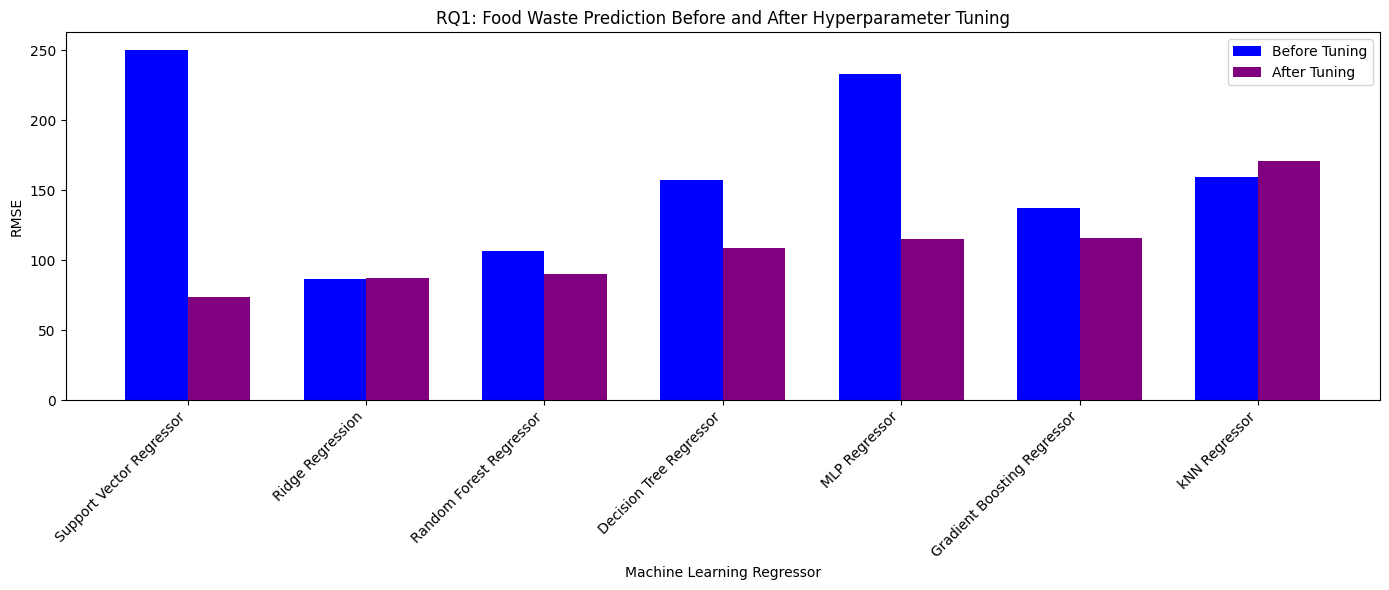

In [ ]:
# ============================================================
# RQ1: GRAPH BEFORE VS AFTER TUNING
# ============================================================

rq1_plot_df = rq1_comparison_rounded.copy()
rq1_plot_df = rq1_plot_df.sort_values(by="After RMSE")

models = rq1_plot_df["Model"]
before_rmse = rq1_plot_df["Before RMSE"]
after_rmse = rq1_plot_df["After RMSE"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(14, 6))

plt.bar(
    x - width / 2,
    before_rmse,
    width,
    label="Before Tuning",
    color="blue"
)

plt.bar(
    x + width / 2,
    after_rmse,
    width,
    label="After Tuning",
    color="purple"
)

plt.xlabel("Machine Learning Regressor")
plt.ylabel("RMSE")
plt.title("RQ1: Food Waste Prediction Before and After Hyperparameter Tuning")
plt.xticks(x, models, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# RQ1: AUTO-GENERATED ANSWER
# ============================================================

rq1_best_rmse = rq1_combined_results.iloc[0]["RMSE"]
rq1_best_mae = rq1_combined_results.iloc[0]["MAE"]
rq1_best_r2 = rq1_combined_results.iloc[0]["Test R2"]

print("\nRQ1 Answer")
print("=" * 70)

print(f"""
RQ1: Can we accurately predict daily food waste volume in kg?

Based on the regression model results, the best-performing model was {rq1_best_model_name}.
It achieved an RMSE of {rq1_best_rmse:.4f}, MAE of {rq1_best_mae:.4f}, and R² score of {rq1_best_r2:.4f}.

This shows that machine learning can be used to predict daily food waste volume.
The prediction accuracy depends on the RMSE and R² score. A lower RMSE means the model has smaller prediction error, while a higher R² score means the model explains more variation in food waste volume.
""")


RQ1 Answer

RQ1: Can we accurately predict daily food waste volume in kg?

Based on the regression model results, the best-performing model was Support Vector Regressor Tuned.
It achieved an RMSE of 73.6618, MAE of 24.6400, and R² score of 0.9143.

This shows that machine learning can be used to predict daily food waste volume.
The prediction accuracy depends on the RMSE and R² score. A lower RMSE means the model has smaller prediction error, while a higher R² score means the model explains more variation in food waste volume.



**RQ2 : What factors influence food waste?**

In [ ]:
# ============================================================
# PART B - RQ2
# What factors influence food waste?
# Dataset 1: Food Waste
# Method: Feature Importance
# ============================================================

print("\nPART B - RQ2: Factors Influencing Food Waste")
print("=" * 70)

rq2_feature_model = RandomForestRegressor(random_state=42)
rq2_feature_model.fit(X1_train_scaled, y1_train)

rq2_feature_importance = pd.DataFrame({
    "Feature": X1_train_scaled.columns,
    "Importance": rq2_feature_model.feature_importances_
})

rq2_feature_importance = rq2_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Factors Influencing Food Waste")
print("=" * 70)

display(rq2_feature_importance.head(10))


PART B - RQ2: Factors Influencing Food Waste

Top 10 Factors Influencing Food Waste


,Feature,Importance
0,Country,0.891636
10,Source,0.029194
5,Retail estimate (tonnes/year),0.019387
3,Household estimate (tonnes/year),0.013836
7,Food service estimate (tonnes/year),0.013758
1,combined figures (kg/capita/year),0.011347
2,Household estimate (kg/capita/year),0.010506
9,Region,0.008832
6,Food service estimate (kg/capita/year),0.000858
4,Retail estimate (kg/capita/year),0.000374


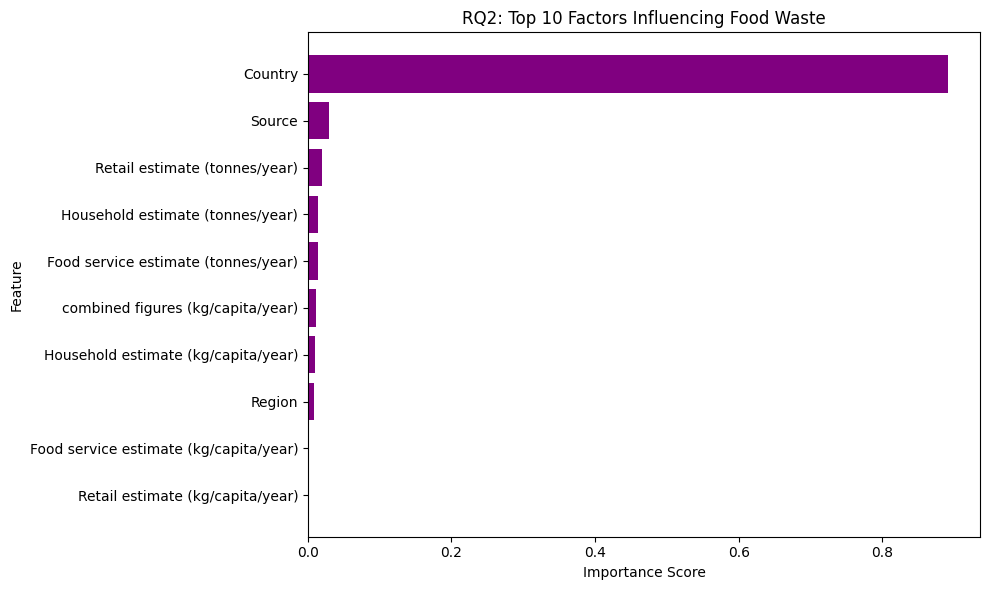

In [ ]:
# ============================================================
# RQ2: FEATURE IMPORTANCE GRAPH
# ============================================================

rq2_top_features = rq2_feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    rq2_top_features["Feature"],
    rq2_top_features["Importance"],
    color="purple"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("RQ2: Top 10 Factors Influencing Food Waste")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# RQ2: AUTO-GENERATED ANSWER
# ============================================================

rq2_top_feature = rq2_feature_importance.iloc[0]["Feature"]
rq2_top_importance = rq2_feature_importance.iloc[0]["Importance"]

print("\nRQ2 Answer")
print("=" * 70)

print(f"""
RQ2: What factors influence food waste?

Based on the Random Forest feature importance analysis, the most influential factor was "{rq2_top_feature}", with an importance score of {rq2_top_importance:.4f}.

The top-ranked features contribute the most to predicting food waste volume.
This means that these variables have the strongest relationship with the food waste target in the dataset.
Therefore, the feature importance result helps identify which factors should be monitored closely to reduce food waste.
""")


RQ2 Answer

RQ2: What factors influence food waste?

Based on the Random Forest feature importance analysis, the most influential factor was "Country", with an importance score of 0.8916.

The top-ranked features contribute the most to predicting food waste volume.
This means that these variables have the strongest relationship with the food waste target in the dataset.
Therefore, the feature importance result helps identify which factors should be monitored closely to reduce food waste.



**RQ3 : Do sales patterns help identify food waste risk?**

In [ ]:
# ============================================================
# PART B - RQ3
# Do sales patterns help identify food waste risk?
# Dataset 2: Restaurant Sales
# Model type: Classification
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

print("\nPART B - RQ3: Sales-Based Food Waste Risk Classification")
print("=" * 70)

print("Training data:", X2_train_scaled.shape)
print("Testing data :", X2_test_scaled.shape)

print("\nTraining target distribution:")
print(y2_train.value_counts())

print("\nTesting target distribution:")
print(y2_test.value_counts())


PART B - RQ3: Sales-Based Food Waste Risk Classification
Training data: (203, 19)
Testing data : (51, 19)

Training target distribution:
waste_risk
0    103
1    100
Name: count, dtype: int64

Testing target distribution:
waste_risk
0    26
1    25
Name: count, dtype: int64


In [ ]:
# ============================================================
# RQ3: CLASSIFICATION EVALUATION FUNCTION
# ============================================================

def evaluate_classification_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    result = {
        "Model": model_name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Train Accuracy : {train_accuracy:.4f}")
    print(f"Test Accuracy  : {test_accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")

    return result

In [ ]:
# ============================================================
# RQ3: BASELINE CLASSIFICATION MODELS
# ============================================================

rq3_models = {
    "k-Nearest Neighbors": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "MLP Classifier": MLPClassifier(max_iter=1000, random_state=42)
}

rq3_baseline_results = []

for model_name, model in rq3_models.items():
    result = evaluate_classification_model(
        model_name,
        model,
        X2_train_scaled,
        X2_test_scaled,
        y2_train,
        y2_test
    )

    rq3_baseline_results.append(result)

rq3_baseline_df = pd.DataFrame(rq3_baseline_results)

print("\nRQ3 Baseline Classification Results")
print("=" * 70)

display(rq3_baseline_df.sort_values(by="F1 Score", ascending=False))


k-Nearest Neighbors
----------------------------------------
Train Accuracy : 0.8916
Test Accuracy  : 0.9216
Precision      : 0.9200
Recall         : 0.9200
F1 Score       : 0.9200

Logistic Regression
----------------------------------------
Train Accuracy : 0.9803
Test Accuracy  : 0.9804
Precision      : 0.9615
Recall         : 1.0000
F1 Score       : 0.9804

Gaussian Naive Bayes
----------------------------------------
Train Accuracy : 0.8374
Test Accuracy  : 0.8824
Precision      : 0.8519
Recall         : 0.9200
F1 Score       : 0.8846

Support Vector Machine
----------------------------------------
Train Accuracy : 0.9655
Test Accuracy  : 0.9804
Precision      : 0.9615
Recall         : 1.0000
F1 Score       : 0.9804

Decision Tree
----------------------------------------
Train Accuracy : 1.0000
Test Accuracy  : 1.0000
Precision      : 1.0000
Recall         : 1.0000
F1 Score       : 1.0000

Random Forest
----------------------------------------
Train Accuracy : 1.0000
Test Accurac

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
7,MLP Classifier,0.990148,1.000000,1.000000,1.00,1.000000
6,Gradient Boosting,1.000000,1.000000,1.000000,1.00,1.000000
5,Random Forest,1.000000,1.000000,1.000000,1.00,1.000000
4,Decision Tree,1.000000,1.000000,1.000000,1.00,1.000000
3,Support Vector Machine,0.965517,0.980392,0.961538,1.00,0.980392
1,Logistic Regression,0.980296,0.980392,0.961538,1.00,0.980392
0,k-Nearest Neighbors,0.891626,0.921569,0.920000,0.92,0.920000
2,Gaussian Naive Bayes,0.837438,0.882353,0.851852,0.92,0.884615


In [ ]:
# ============================================================
# RQ3: HYPERPARAMETER TUNING
# ============================================================

rq3_param_grids = {
    "k-Nearest Neighbors": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"],
        "p": [1, 2]
    },

    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    },

    "Gaussian Naive Bayes": {
        "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
    },

    "Support Vector Machine": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },

    "Decision Tree": {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "n_estimators": [50, 100],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "Gradient Boosting": {
        "n_estimators": [50, 100],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 5]
    },

    "MLP Classifier": {
        "hidden_layer_sizes": [(50,), (100,), (50, 50)],
        "activation": ["relu", "tanh"],
        "alpha": [0.0001, 0.001],
        "learning_rate": ["constant", "adaptive"]
    }
}

rq3_tuning_models = {
    "k-Nearest Neighbors": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "MLP Classifier": MLPClassifier(max_iter=1000, random_state=42)
}

rq3_tuned_results = []
rq3_best_models = {}

rq3_min_class_count = y2_train.value_counts().min()
rq3_cv = min(5, rq3_min_class_count)

if rq3_cv < 2:
    raise ValueError("Not enough samples in each class for cross-validation.")

for model_name, model in rq3_tuning_models.items():
    print(f"\nTuning {model_name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=rq3_param_grids[model_name],
        cv=rq3_cv,
        scoring="f1",
        n_jobs=-1
    )

    grid_search.fit(X2_train_scaled, y2_train)

    best_model = grid_search.best_estimator_
    rq3_best_models[model_name] = best_model

    print("Best parameters:")
    print(grid_search.best_params_)

    result = evaluate_classification_model(
        model_name + " Tuned",
        best_model,
        X2_train_scaled,
        X2_test_scaled,
        y2_train,
        y2_test
    )

    rq3_tuned_results.append(result)

rq3_tuned_df = pd.DataFrame(rq3_tuned_results)

print("\nRQ3 Tuned Classification Results")
print("=" * 70)

display(rq3_tuned_df.sort_values(by="F1 Score", ascending=False))


Tuning k-Nearest Neighbors...
Best parameters:
{'n_neighbors': 9, 'p': 2, 'weights': 'distance'}

k-Nearest Neighbors Tuned
----------------------------------------
Train Accuracy : 1.0000
Test Accuracy  : 0.9412
Precision      : 0.9231
Recall         : 0.9600
F1 Score       : 0.9412

Tuning Logistic Regression...
Best parameters:
{'C': 1, 'solver': 'liblinear'}

Logistic Regression Tuned
----------------------------------------
Train Accuracy : 0.9803
Test Accuracy  : 0.9608
Precision      : 0.9600
Recall         : 0.9600
F1 Score       : 0.9600

Tuning Gaussian Naive Bayes...
Best parameters:
{'var_smoothing': 1e-09}

Gaussian Naive Bayes Tuned
----------------------------------------
Train Accuracy : 0.8374
Test Accuracy  : 0.8824
Precision      : 0.8519
Recall         : 0.9200
F1 Score       : 0.8846

Tuning Support Vector Machine...
Best parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}

Support Vector Machine Tuned
----------------------------------------
Train Accurac

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
5,Random Forest Tuned,1.000000,1.000000,1.000000,1.00,1.000000
6,Gradient Boosting Tuned,0.990148,1.000000,1.000000,1.00,1.000000
4,Decision Tree Tuned,1.000000,1.000000,1.000000,1.00,1.000000
7,MLP Classifier Tuned,0.970443,0.980392,0.961538,1.00,0.980392
3,Support Vector Machine Tuned,0.985222,0.960784,0.960000,0.96,0.960000
1,Logistic Regression Tuned,0.980296,0.960784,0.960000,0.96,0.960000
0,k-Nearest Neighbors Tuned,1.000000,0.941176,0.923077,0.96,0.941176
2,Gaussian Naive Bayes Tuned,0.837438,0.882353,0.851852,0.92,0.884615


In [ ]:
# ============================================================
# RQ3: SIDE-BY-SIDE COMPARISON
# BEFORE VS AFTER TUNING
# ============================================================

rq3_before = rq3_baseline_df.copy()
rq3_after = rq3_tuned_df.copy()

# Remove " Tuned" word from tuned model names
rq3_after["Model"] = rq3_after["Model"].str.replace(" Tuned", "", regex=False)

# Rename before tuning columns
rq3_before = rq3_before.rename(columns={
    "Train Accuracy": "Before Train Accuracy",
    "Test Accuracy": "Before Test Accuracy",
    "Precision": "Before Precision",
    "Recall": "Before Recall",
    "F1 Score": "Before F1 Score"
})

# Rename after tuning columns
rq3_after = rq3_after.rename(columns={
    "Train Accuracy": "After Train Accuracy",
    "Test Accuracy": "After Test Accuracy",
    "Precision": "After Precision",
    "Recall": "After Recall",
    "F1 Score": "After F1 Score"
})

# Merge before and after results
rq3_comparison = pd.merge(
    rq3_before,
    rq3_after,
    on="Model",
    how="inner"
)

rq3_comparison["Accuracy Improvement"] = (
    rq3_comparison["After Test Accuracy"] -
    rq3_comparison["Before Test Accuracy"]
)

rq3_comparison["F1 Improvement"] = (
    rq3_comparison["After F1 Score"] -
    rq3_comparison["Before F1 Score"]
)

# Arrange columns as Before, After, Before, After
rq3_comparison = rq3_comparison[
    [
        "Model",
        "Before Train Accuracy", "After Train Accuracy",
        "Before Test Accuracy", "After Test Accuracy",
        "Before Precision", "After Precision",
        "Before Recall", "After Recall",
        "Before F1 Score", "After F1 Score",
        "Accuracy Improvement",
        "F1 Improvement"
    ]
]

# Sort by best after tuning F1 score
rq3_comparison = rq3_comparison.sort_values(
    by="After F1 Score",
    ascending=False
)

# Round values
rq3_comparison_rounded = rq3_comparison.round(4)

print("\nRQ3 Side-by-Side Comparison: Before vs After Tuning")
print("=" * 70)

display(rq3_comparison_rounded)


RQ3 Side-by-Side Comparison: Before vs After Tuning


,Model,Before Train Accuracy,After Train Accuracy,Before Test Accuracy,After Test Accuracy,Before Precision,After Precision,Before Recall,After Recall,Before F1 Score,After F1 Score,Accuracy Improvement,F1 Improvement
5,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.00,1.00,1.0000,1.0000,0.0000,0.0000
6,Gradient Boosting,1.0000,0.9901,1.0000,1.0000,1.0000,1.0000,1.00,1.00,1.0000,1.0000,0.0000,0.0000
4,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.00,1.00,1.0000,1.0000,0.0000,0.0000
7,MLP Classifier,0.9901,0.9704,1.0000,0.9804,1.0000,0.9615,1.00,1.00,1.0000,0.9804,-0.0196,-0.0196
3,Support Vector Machine,0.9655,0.9852,0.9804,0.9608,0.9615,0.9600,1.00,0.96,0.9804,0.9600,-0.0196,-0.0204
1,Logistic Regression,0.9803,0.9803,0.9804,0.9608,0.9615,0.9600,1.00,0.96,0.9804,0.9600,-0.0196,-0.0204
0,k-Nearest Neighbors,0.8916,1.0000,0.9216,0.9412,0.9200,0.9231,0.92,0.96,0.9200,0.9412,0.0196,0.0212
2,Gaussian Naive Bayes,0.8374,0.8374,0.8824,0.8824,0.8519,0.8519,0.92,0.92,0.8846,0.8846,0.0000,0.0000


In [ ]:
# ============================================================
# RQ3: SELECT BEST CLASSIFIER
# ============================================================

rq3_combined_results = pd.concat(
    [rq3_baseline_df, rq3_tuned_df],
    ignore_index=True
)

rq3_combined_results = rq3_combined_results.sort_values(
    by="F1 Score",
    ascending=False
)

rq3_best_model_name = rq3_combined_results.iloc[0]["Model"]

print("\nRQ3 Best Classifier Based on Highest F1 Score")
print("=" * 70)

print(f"Best model    : {rq3_best_model_name}")
print(f"Best F1 Score : {rq3_combined_results.iloc[0]['F1 Score']:.4f}")
print(f"Best Accuracy : {rq3_combined_results.iloc[0]['Test Accuracy']:.4f}")
print(f"Best Precision: {rq3_combined_results.iloc[0]['Precision']:.4f}")
print(f"Best Recall   : {rq3_combined_results.iloc[0]['Recall']:.4f}")

if "Tuned" in rq3_best_model_name:
    rq3_original_name = rq3_best_model_name.replace(" Tuned", "")
    rq3_final_best_model = rq3_best_models[rq3_original_name]
else:
    rq3_final_best_model = rq3_models[rq3_best_model_name]
    rq3_final_best_model.fit(X2_train_scaled, y2_train)

os.makedirs("/content/rq3_waste_risk_classification", exist_ok=True)

rq3_combined_results.to_csv(
    "/content/rq3_waste_risk_classification/rq3_model_results.csv",
    index=False
)

joblib.dump(
    rq3_final_best_model,
    "/content/rq3_waste_risk_classification/rq3_best_model.pkl"
)


RQ3 Best Classifier Based on Highest F1 Score
Best model    : MLP Classifier
Best F1 Score : 1.0000
Best Accuracy : 1.0000
Best Precision: 1.0000
Best Recall   : 1.0000


['/content/rq3_waste_risk_classification/rq3_best_model.pkl']

In [ ]:
# ============================================================
# RQ3: CONFUSION MATRIX AND CLASSIFICATION REPORT
# ============================================================

rq3_y_pred_best = rq3_final_best_model.predict(X2_test_scaled)

print("\nRQ3 Confusion Matrix")
print("=" * 70)
print(confusion_matrix(y2_test, rq3_y_pred_best))

print("\nRQ3 Classification Report")
print("=" * 70)
print(classification_report(y2_test, rq3_y_pred_best))


RQ3 Confusion Matrix
[[26  0]
 [ 0 25]]

RQ3 Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        25

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51



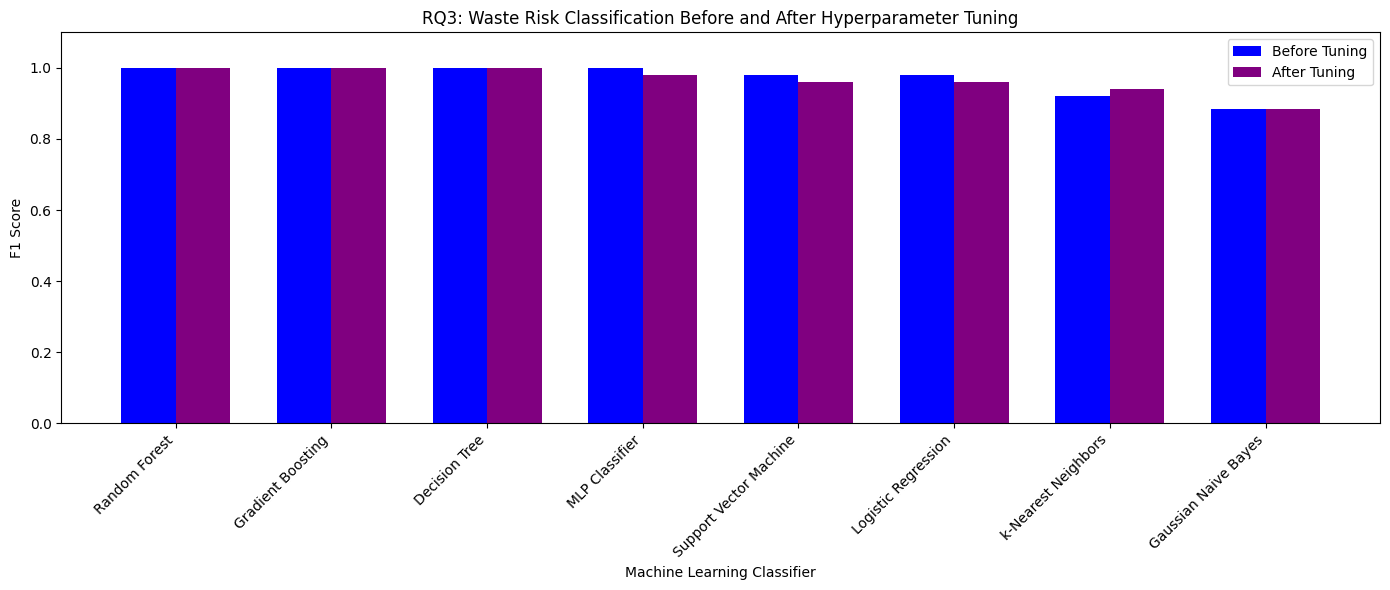

In [ ]:
# ============================================================
# RQ3: GRAPH BEFORE VS AFTER TUNING
# ============================================================

rq3_plot_df = rq3_comparison_rounded.copy()
rq3_plot_df = rq3_plot_df.sort_values(by="After F1 Score", ascending=False)

models = rq3_plot_df["Model"]
before_f1 = rq3_plot_df["Before F1 Score"]
after_f1 = rq3_plot_df["After F1 Score"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(14, 6))

plt.bar(
    x - width / 2,
    before_f1,
    width,
    label="Before Tuning",
    color="blue"
)

plt.bar(
    x + width / 2,
    after_f1,
    width,
    label="After Tuning",
    color="purple"
)

plt.xlabel("Machine Learning Classifier")
plt.ylabel("F1 Score")
plt.title("RQ3: Waste Risk Classification Before and After Hyperparameter Tuning")
plt.xticks(x, models, rotation=45, ha="right")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# RQ3: AUTO-GENERATED ANSWER
# ============================================================

rq3_best_f1 = rq3_combined_results.iloc[0]["F1 Score"]
rq3_best_acc = rq3_combined_results.iloc[0]["Test Accuracy"]
rq3_best_precision = rq3_combined_results.iloc[0]["Precision"]
rq3_best_recall = rq3_combined_results.iloc[0]["Recall"]

print("\nRQ3 Answer")
print("=" * 70)

print(f"""
RQ3: Do sales patterns help identify food waste risk?

Based on the classification results, the best-performing classifier was {rq3_best_model_name}.
It achieved an accuracy of {rq3_best_acc:.4f}, precision of {rq3_best_precision:.4f}, recall of {rq3_best_recall:.4f}, and F1-score of {rq3_best_f1:.4f}.

This shows that restaurant sales patterns can help identify food waste risk.
The model can classify records into low-risk and high-risk waste categories, which supports better planning and decision-making to reduce food waste indirectly.
""")


RQ3 Answer

RQ3: Do sales patterns help identify food waste risk?

Based on the classification results, the best-performing classifier was MLP Classifier.
It achieved an accuracy of 1.0000, precision of 1.0000, recall of 1.0000, and F1-score of 1.0000.

This shows that restaurant sales patterns can help identify food waste risk.
The model can classify records into low-risk and high-risk waste categories, which supports better planning and decision-making to reduce food waste indirectly.



# Files Download

In [ ]:
from google.colab import files
import os

# Zip and download
!zip -r food_waste_processed.zip /content/food_waste_processed/
!zip -r sales_processed.zip /content/sales_processed/

files.download('food_waste_processed.zip')
files.download('sales_processed.zip')

# Download notebooks (if in /content/)
if os.path.exists('/content/food_waste_preprocessing.ipynb'):
    files.download('/content/food_waste_preprocessing.ipynb')
if os.path.exists('/content/sales_preprocessing.ipynb'):
    files.download('/content/sales_preprocessing.ipynb')

print("Download complete!")

updating: content/food_waste_processed/ (stored 0%)
updating: content/food_waste_processed/y1_test.csv (deflated 38%)
updating: content/food_waste_processed/label_encoders1.pkl (deflated 85%)
updating: content/food_waste_processed/scaler1.pkl (deflated 36%)
updating: content/food_waste_processed/X1_test_scaled.csv (deflated 66%)
updating: content/food_waste_processed/y1_train.csv (deflated 50%)
updating: content/food_waste_processed/X1_train_scaled.csv (deflated 71%)
updating: content/sales_processed/ (stored 0%)
updating: content/sales_processed/label_encoders2.pkl (deflated 62%)
updating: content/sales_processed/X2_train_scaled.csv (deflated 88%)
updating: content/sales_processed/y2_test.csv (deflated 67%)
updating: content/sales_processed/X2_test_scaled.csv (deflated 83%)
updating: content/sales_processed/scaler2.pkl (deflated 32%)
updating: content/sales_processed/y2_train.csv (deflated 80%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete!
